In [3]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [4]:
load_dotenv()

True

In [5]:
MODEL = "gpt-5.4-mini"

In [6]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [7]:
@tool 
def weather():
    """
    Tool func where weather api data is called and fetched 
    """

    return "The weather is sunny today"

@tool 
def websearch():
    """
    Tool func for web search
    """

    return "SCRAPPED DATA: Bitcoin has fallen down to the last support level!" 


@tool
def calculate():
    """
    Tool func used in case of calculation needed
    """ 

    result = 43 
    return result    

In [86]:
tools = [weather, websearch, calculate]
llm = ChatOpenAI(model=MODEL).bind_tools(tools)

In [122]:
def llm_agent(state):
    system_message = SystemMessage(content="You are a helpful assistant answering user queries. Dont speak too briefly, make your words rich and detailed enough")

    response = llm.invoke([system_message] + state["messages"])
    # print("AI: ", response.content)
    
    return {"messages": [response]}

In [131]:
def should_continue(state): 
    """
    Conditional node that decides whether to continue or end the tool calling
    """

    messages = state["messages"]
    last_message = messages[-1]

    if not getattr(last_message, "tool_calls", None):
        return "end"
    else:
        return "continue"

In [132]:
builder = StateGraph(State)

builder.add_node("llm_agent", llm_agent)

tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)

builder.add_edge(START, "llm_agent")
builder.add_conditional_edges(
    "llm_agent",
    should_continue,
    {
        "continue": "tools",
        "end": END
    }
)
builder.add_edge("tools", "llm_agent")

graph = builder.compile()

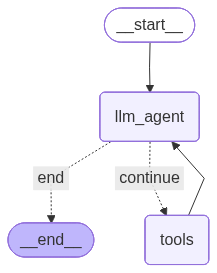

In [133]:
builder.compile()

In [139]:
### Output

input_arg = {
    "messages": [
        ("user", "whats the weather today? Give me a long dailyweather report and second question is how's bitcoin going?")
    ]
}

result = graph.invoke(input_arg)

for msg in result["messages"]:
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(type(msg).__name__, ":", msg.tool_calls)
    else:
        print(type(msg).__name__, ":", msg.content)

HumanMessage : whats the weather today? Give me a long dailyweather report and second question is how's bitcoin going?
AIMessage : [{'name': 'weather', 'args': {}, 'id': 'call_tlKr8ki7sdIdZ80UXhvq46A6', 'type': 'tool_call'}, {'name': 'websearch', 'args': {}, 'id': 'call_B2e0XDuu8je7t8AJso1s8fGR', 'type': 'tool_call'}]
ToolMessage : The weather is sunny today
ToolMessage : SCRAPPED DATA: Bitcoin has fallen down to the last support level!
AIMessage : Here’s a concise daily update for both:

## Weather today
It’s **sunny today**. That usually means a bright, clear day with good visibility and generally pleasant conditions. If you’re heading out, it’s a good idea to wear sunglasses and consider sunscreen, especially if you’ll be outside for a while. Since I only received a brief weather summary, I can’t give exact temperatures, wind speed, or precipitation chances—but the overall outlook sounds calm and favorable.

## Bitcoin update
Bitcoin appears to have **fallen down to a key support le